In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

facts = pd.read_csv('FactSales 1.csv')
products = pd.read_csv('DimProducts 1.csv')
customers = pd.read_csv('DimCustomers 1.csv')
managers = pd.read_csv('DimManagers 1.csv')

print("FactSales:", facts.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)
print("Managers:", managers.shape)

FactSales: (7479, 9)
Products: (120, 5)
Customers: (500, 5)
Managers: (8, 4)


In [11]:
print("=== FactSales ===")
print(facts.head())
print("\nТипы данных:")
print(facts.dtypes)
print("\nПропуски:")
print(facts.isnull().sum())

=== FactSales ===
  OrderID   OrderDate CustomerID ProductID ManagerID  Quantity  UnitPrice  \
0  O10000  2025-12-21      C1028     P1070      M102         4     796.08   
1  O10000  2025-12-21      C1028     P1008      M102         3     790.71   
2  O10001  2025-07-02      C1349     P1114      M103         5     780.79   
3  O10002  2024-03-22      C1046     P1098      M107         2     764.83   
4  O10002  2024-03-22      C1046     P1009      M107         5     119.53   

   DiscountPct    Cost  
0         0.20  516.36  
1         0.00  469.30  
2         0.00  398.25  
3         0.10  555.57  
4         0.15   76.15  

Типы данных:
OrderID         object
OrderDate       object
CustomerID      object
ProductID       object
ManagerID       object
Quantity         int64
UnitPrice      float64
DiscountPct    float64
Cost           float64
dtype: object

Пропуски:
OrderID         0
OrderDate       0
CustomerID      0
ProductID       0
ManagerID      10
Quantity        0
UnitPrice      

In [12]:
# Исправляем тип даты
facts['OrderDate'] = pd.to_datetime(facts['OrderDate'])

# Смотрим пропуски в ManagerID
print("Строки с пустым ManagerID:")
print(facts[facts['ManagerID'].isnull()])

# Заполняем пропуски — 'Unknown'
facts['ManagerID'] = facts['ManagerID'].fillna('Unknown')

print("\nПропуски после исправления:")
print(facts.isnull().sum())
print("\nТип OrderDate:", facts['OrderDate'].dtype)

Строки с пустым ManagerID:
     OrderID  OrderDate CustomerID ProductID ManagerID  Quantity  UnitPrice  \
104   O10039 2025-07-22      C1372     P1074       NaN         2     863.51   
695   O10267 2024-11-17      C1079     P1032       NaN         3     249.12   
1473  O10576 2024-04-07      C1231     P1022       NaN         5     854.75   
2632  O11029 2024-07-05      C1168     P1020       NaN         3     252.39   
3335  O11311 2025-05-22      C1046     P1093       NaN         3     737.03   
3543  O11391 2024-12-11      C1057     P1011       NaN         4     394.88   
3789  O11493 2024-07-12      C1137     P1049       NaN         1     265.39   
4413  O11753 2024-06-09      C1024     P1099       NaN         4     209.17   
4979  O11983 2024-08-06      C1291     P1065       NaN         5     627.48   
7460  O12991 2024-04-04      C1336     P1006       NaN         1     574.10   

      DiscountPct    Cost  
104          0.00  517.00  
695          0.05  171.99  
1473         0.00  

In [13]:
# Считаем Revenue (выручка с учётом скидки)
facts['Revenue'] = facts['Quantity'] * facts['UnitPrice'] * (1 - facts['DiscountPct'])
facts['GrossProfit'] = facts['Revenue'] - (facts['Quantity'] * facts['Cost'])

print("Общая выручка: ${:,.0f}".format(facts['Revenue'].sum()))
print("Общая прибыль: ${:,.0f}".format(facts['GrossProfit'].sum()))
print("Средняя маржа: {:.1f}%".format(
    (facts['GrossProfit'].sum() / facts['Revenue'].sum()) * 100
))

Общая выручка: $10,164,530
Общая прибыль: $2,817,366
Средняя маржа: 27.7%


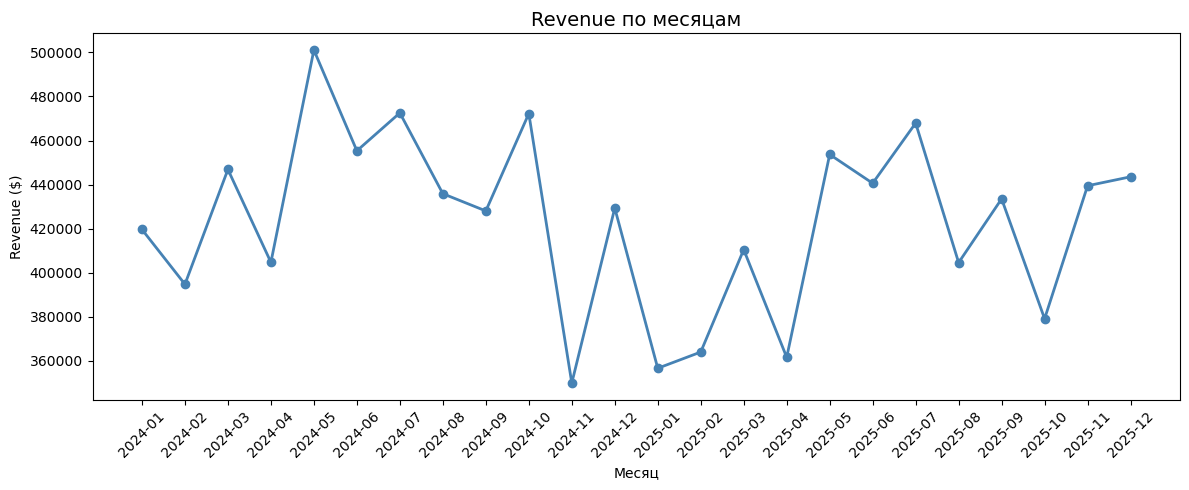

In [14]:
# Revenue по месяцам
facts['Month'] = facts['OrderDate'].dt.to_period('M')
monthly = facts.groupby('Month')['Revenue'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly['Month'], monthly['Revenue'], marker='o', color='steelblue', linewidth=2)
plt.title('Revenue по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

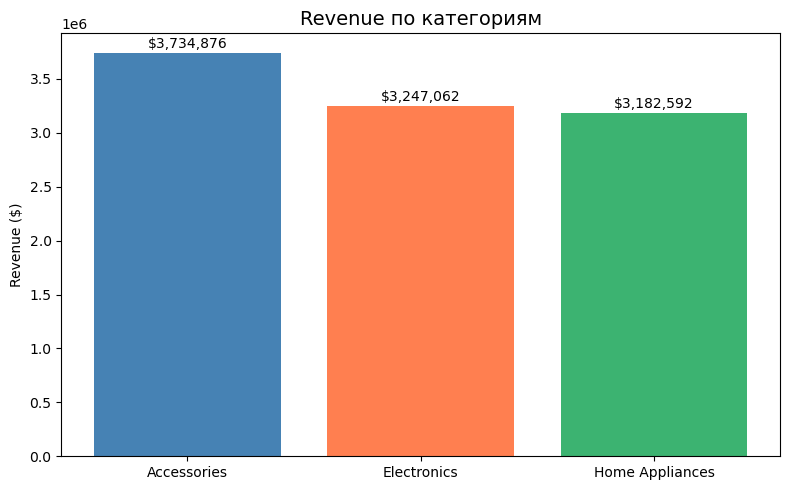

In [15]:
# Джойним с продуктами и смотрим по категориям
merged = facts.merge(products, on='ProductID', how='left')

category_revenue = merged.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(category_revenue.index, category_revenue.values, color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Revenue по категориям', fontsize=14)
plt.ylabel('Revenue ($)')

# Добавляем цифры на столбики
for bar, val in zip(bars, category_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
             '${:,.0f}'.format(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

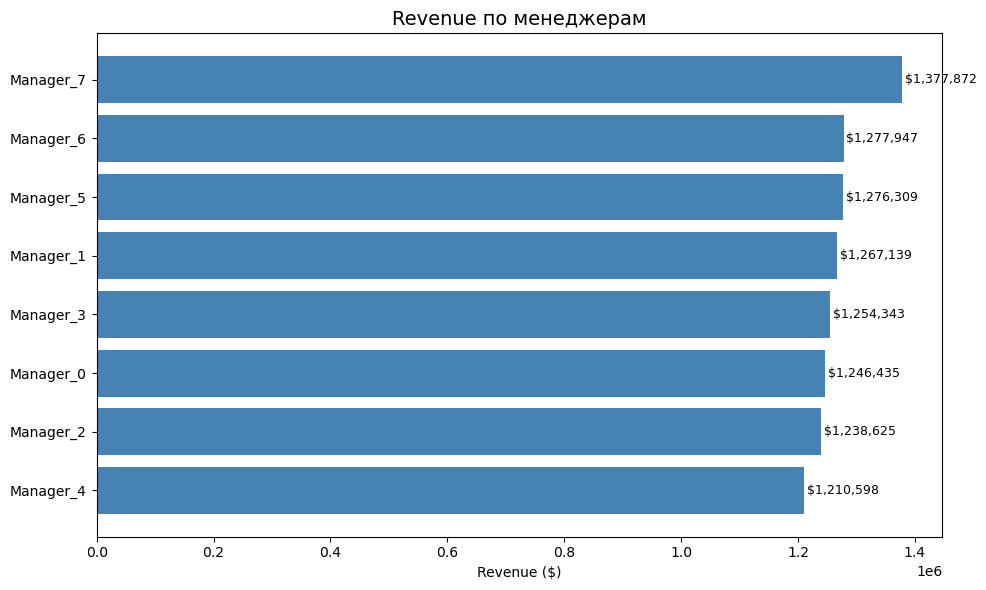

  ManagerName       Revenue  Margin%  Orders
4   Manager_4  1.210598e+06     27.1     363
2   Manager_2  1.238625e+06     27.2     380
0   Manager_0  1.246435e+06     27.7     382
3   Manager_3  1.254343e+06     28.5     376
1   Manager_1  1.267139e+06     27.7     372
5   Manager_5  1.276309e+06     27.8     392
6   Manager_6  1.277947e+06     28.5     354
7   Manager_7  1.377872e+06     27.2     380


In [16]:
  # Revenue по менеджерам
merged2 = facts.merge(managers, on='ManagerID', how='left')

manager_stats = merged2.groupby('ManagerName').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('OrderID', 'nunique'),
    GrossProfit=('GrossProfit', 'sum')
).reset_index()

manager_stats['Margin%'] = (manager_stats['GrossProfit'] / manager_stats['Revenue'] * 100).round(1)
manager_stats = manager_stats.sort_values('Revenue', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(manager_stats['ManagerName'], manager_stats['Revenue'], color='steelblue')
plt.title('Revenue по менеджерам', fontsize=14)
plt.xlabel('Revenue ($)')

for bar, val in zip(bars, manager_stats['Revenue']):
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             '${:,.0f}'.format(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(manager_stats[['ManagerName', 'Revenue', 'Margin%', 'Orders']])